In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import layers, models

In [2]:
path = '/content/drive/MyDrive/Colab Notebooks/breast_cancer.csv'
df = pd.read_csv(path)

In [49]:
X=df.drop('label', axis=1)
X.head()

y=df['label']
y.value_counts()

,count
label,
1,357
0,212


In [51]:
from tensorflow.keras import layers, models
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
Y = y.values

In [52]:
from sklearn.model_selection import train_test_split
X_train,X_test, y_train,y_test = train_test_split(X,Y,test_size=0.2,random_state=0)


In [53]:
model = models.Sequential([
    layers.Input(shape=(X_train.shape[1],)), # 현재 31인 X_train의 컬럼 수를 자동으로 입력
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(32, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

In [54]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"])

model.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_32 (Dense)                │ (None, 64)             │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,161 (16.25 KB)

 Trainable params: 4,161 (16.25 KB)

 Non-trainable params: 0 (0.00 B)

In [46]:
print(X_train.shape)


(455, 31)


In [55]:
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=16,
    verbose=1
)

Epoch 1/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5275 - loss: 22.6349 - val_accuracy: 0.8242 - val_loss: 2.6853
Epoch 2/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7170 - loss: 11.4129 - val_accuracy: 0.8242 - val_loss: 4.7611
Epoch 3/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7720 - loss: 9.0196 - val_accuracy: 0.8242 - val_loss: 5.2714
Epoch 4/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7637 - loss: 8.6218 - val_accuracy: 0.8242 - val_loss: 3.7637
Epoch 5/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8132 - loss: 4.9420 - val_accuracy: 0.8242 - val_loss: 4.0113
Epoch 6/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8434 - loss: 3.8020 - val_accuracy: 0.9341 - val_loss: 1.6419
Epoch 7/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8434 - loss: 3.4439 - val_accuracy: 0.8791 - val_loss: 2.1156
Epoch 8/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8297 - loss: 3.8851 - val_accuracy: 0.9011 - val_los

In [64]:
y_pred = model.predict(X_test)
y_pred_class = (y_pred > 0.5).astype(int).flatten()  # argmax 불필요
y_test_class = y_test

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


In [65]:
import matplotlib.pyplot as plt
import seaborn as sns

In [66]:
# 학습 곡선
loss = history.history['loss']
val_loss = history.history['val_loss']
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

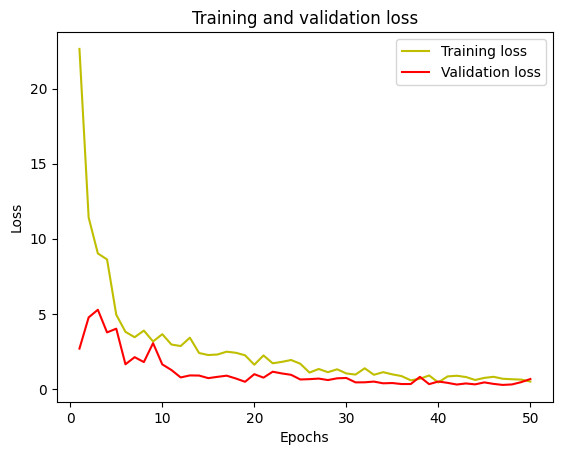

In [67]:
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(loss) + 1)

plt.plot(epochs, loss, 'y', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

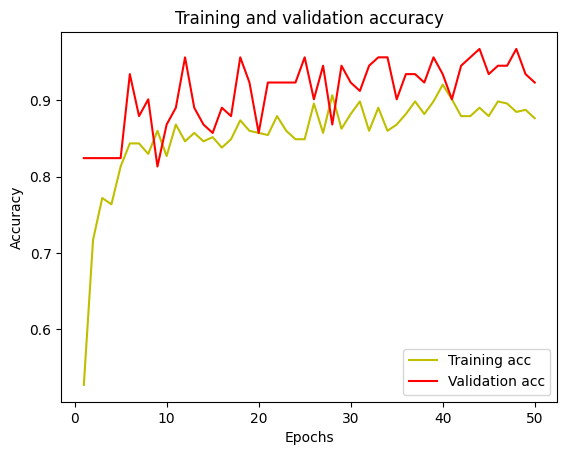

In [68]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

plt.plot(epochs, acc, 'y', label='Training acc')
plt.plot(epochs, val_acc, 'r', label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [69]:
#Accuracy of the predicted values
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(y_test_class,y_pred_class))
print(confusion_matrix(y_test_class,y_pred_class))

              precision    recall  f1-score   support

           0       1.00      0.68      0.81        47
           1       0.82      1.00      0.90        67

    accuracy                           0.87       114
   macro avg       0.91      0.84      0.85       114
weighted avg       0.89      0.87      0.86       114

[[32 15]
 [ 0 67]]
